# HR simul_new: per-node samples vs. component error

For every run under `HR_dyn/results_simul_new/...`, we support two loading modes:
1. `SELECT_EPOCH = 2500` (or any integer): read exactly `metrics_snapshot_e{SELECT_EPOCH}.json`.
2. `SELECT_EPOCH = None` (default): scan all `metrics_snapshot_e*.json` files from epoch 1100 to 2500 and select the best snapshot for each metric family.

HR snapshots already store **error** values, not corr²:
1. `component_mean_err`: use the minimum `best_component_mean_err` over snapshots.
2. `component_max_err`: for every snapshot compute `max(self_x_err, self_y_err, self_z_err, msg_err)` and select the minimum.

The four per-component curves come from the same snapshot selected by the **minimum max-error** criterion.


In [21]:
import os, re, sys, json, glob, pickle, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_hex
import torch
import torch.nn.functional as F

# Keep text as editable text (not outlined paths) in Adobe Illustrator.
plt.rcParams['svg.fonttype'] = 'none'   # SVG: text stays as <text>, editable in AI
plt.rcParams['pdf.fonttype'] = 42       # PDF: TrueType embed, editable in AI
plt.rcParams['ps.fonttype']  = 42       # EPS/PS: same, in case we ever export EPS

# Repo layout: this notebook lives at <repo>/HR_dyn/. The training script
# resolves data paths from <repo>/, so we mirror that by cwd-ing to the repo
# root for the rest of the notebook.
NB_DIR = os.path.dirname(os.path.abspath('analyze_subnodes_total_samples_vs_test_r2_new.ipynb')) \
    if os.path.isfile('analyze_subnodes_total_samples_vs_test_r2_new.ipynb') else os.getcwd()
if os.path.basename(os.path.abspath(NB_DIR)) == 'HR_dyn':
    REPO_DIR = os.path.dirname(os.path.abspath(NB_DIR))
else:
    REPO_DIR = os.path.abspath(NB_DIR)
os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
HR_DYN_DIR = os.path.join(REPO_DIR, 'HR_dyn')
if HR_DYN_DIR not in sys.path:
    sys.path.insert(0, HR_DYN_DIR)

from model import (
    tau_soft_regu_deriv_MP,
    get_edge_index,
    calculate_auc,
    evaluate_on_set,
)

RESULTS_DIR = os.path.join(REPO_DIR, 'HR_dyn', 'results_simul_new')
DATA_DIR = os.path.join(REPO_DIR, 'HR_dyn', 'data')
print('REPO_DIR    :', REPO_DIR)
print('RESULTS_DIR :', RESULTS_DIR, '(exists)' if os.path.isdir(RESULTS_DIR) else '(MISSING)')
print('DATA_DIR    :', DATA_DIR,    '(exists)' if os.path.isdir(DATA_DIR) else '(MISSING)')

REPO_DIR    : /DATA/sunyiting/figure4morestructure
RESULTS_DIR : /DATA/sunyiting/figure4morestructure/HR_dyn/results_simul_new (exists)
DATA_DIR    : /DATA/sunyiting/figure4morestructure/HR_dyn/data (exists)


In [22]:
# Mirror constants from HR_dyn/train_simul_HR.py.
NET_NAME = 'Celegans'
T_TOTAL = 500
DT_DATA = 0.01
DIMENSION = 3
DATA_SEED = 1
VALTEST_SEED = 2024
SELECT_EPOCH = None      # int -> use metrics_snapshot_e{epoch}.json; None -> auto-pick best over epochs
AUTO_EPOCH_MIN = 1100
AUTO_EPOCH_MAX = 2500
FINAL_EPOCH = 2500       # kept only for backward compatibility with old helper code
TAU_INIT = 1.0
TAU_DECAY = 0.999
HIDDEN_DEFAULT = 50
MSG_DIM = 1
LAM_DEFAULT = 0.001

TAU_FINAL = TAU_INIT * (TAU_DECAY ** FINAL_EPOCH)
print(f'SELECT_EPOCH={SELECT_EPOCH}')
print(f'AUTO_EPOCH_RANGE=[{AUTO_EPOCH_MIN}, {AUTO_EPOCH_MAX}]')
print(f'reconstructed tau at epoch {FINAL_EPOCH}: {TAU_FINAL:.6f}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


SELECT_EPOCH=None
AUTO_EPOCH_RANGE=[1100, 2500]
reconstructed tau at epoch 2500: 0.081982
device: cuda


In [23]:
# 1-corr² metric — same definition as HR_dyn/train_simul_HR.py.
def one_minus_corr2(a, b):
    a = np.asarray(a).reshape(-1)
    b = np.asarray(b).reshape(-1)
    if a.size == 0 or np.std(a) == 0 or np.std(b) == 0:
        return float('nan')
    c = np.corrcoef(a, b)[0, 1]
    return float(1.0 - c ** 2) if np.isfinite(c) else float('nan')


def strip_compile_prefix(state_dict, prefix='_orig_mod.'):
    """Drop the `_orig_mod.` key prefix that torch.compile wraps around the
    original module when a compiled model's state_dict is saved without first
    unwrapping via `model._orig_mod`. A no-op if no keys carry the prefix."""
    if not any(k.startswith(prefix) for k in state_dict.keys()):
        return state_dict
    return {
        (k[len(prefix):] if k.startswith(prefix) else k): v
        for k, v in state_dict.items()
    }


@torch.no_grad()
def compute_component_metrics(Dyn, X_set, y_set, edge_index, objectAij, device):
    """Recompute the same metrics as HR_dyn/train_simul_HR.py on the test set.
    Adds `component_max_err` which the training script does not currently save."""
    Dyn.eval()

    overall = evaluate_on_set(Dyn, X_set, y_set, edge_index, device)

    T = X_set.shape[0]
    N = X_set.shape[1]
    ei = edge_index.to(device)
    src_idx = ei[0]
    tgt_idx = ei[1]

    # self dynamics on node-level states
    x_flat = X_set.to(device).reshape(T * N, DIMENSION)
    sx = Dyn.node_fnc_x(x_flat).reshape(-1).cpu().numpy()
    sy = Dyn.node_fnc_y(x_flat).reshape(-1).cpu().numpy()
    sz = Dyn.node_fnc_z(x_flat).reshape(-1).cpu().numpy()
    xa = x_flat.cpu().numpy()
    sx_true = xa[:, 1] - xa[:, 0] ** 3 + 3 * xa[:, 0] ** 2 - xa[:, 2] + 3.24
    sy_true = 1.0 - 5.0 * xa[:, 0] ** 2 - xa[:, 1]
    sz_true = 0.004 * (4.0 * (xa[:, 0] + 1.6) - xa[:, 2])

    # message component (per edge × per test sample)
    X_dev = X_set.to(device)
    xi_all = X_dev[:, tgt_idx, 0]
    xj_all = X_dev[:, src_idx, 0]
    xi_flat = xi_all.reshape(-1)
    xj_flat = xj_all.reshape(-1)
    tmp_in = torch.stack([xi_flat, xj_flat], dim=1)
    G_pred_flat = Dyn.msg_fnc(tmp_in).reshape(-1)

    soft_w = F.softmax(Dyn.weights / Dyn.tau, dim=1)[:, 0]
    soft_w_tiled = soft_w.unsqueeze(0).expand(T, -1).reshape(-1)
    msg_pred_weighted = (soft_w_tiled * G_pred_flat).cpu().numpy()

    objA = np.asarray(objectAij)
    mask = np.ones_like(objA, dtype=bool)
    np.fill_diagonal(mask, 0)
    aij_true = objA.T[mask].astype(np.float32)
    xi_n = xi_flat.cpu().numpy()
    xj_n = xj_flat.cpu().numpy()
    G_true_flat = 0.15 * (2.0 - xi_n) / (1.0 + np.exp(-10.0 * (xj_n - 1.0)))
    aij_tiled = np.tile(aij_true, T)
    msg_true_weighted = aij_tiled * G_true_flat

    sx_err = one_minus_corr2(sx_true, sx)
    sy_err = one_minus_corr2(sy_true, sy)
    sz_err = one_minus_corr2(sz_true, sz)
    msg_err = one_minus_corr2(msg_true_weighted, msg_pred_weighted)
    comp_err = float(np.nanmean([sx_err, sy_err, sz_err, msg_err]))
    comp_max = float(np.nanmax([sx_err, sy_err, sz_err, msg_err]))

    try:
        auc, auprc = calculate_auc(objectAij, Dyn.weights)
    except Exception:
        auc, auprc = float('nan'), float('nan')

    return {
        'overall_r2': overall['r2'],
        'node_r2_mean': overall['node_r2_mean'],
        'self_x_err': float(sx_err),
        'self_y_err': float(sy_err),
        'self_z_err': float(sz_err),
        'msg_err': float(msg_err),
        'component_mean_err': comp_err,
        'component_max_err': comp_max,
        'AUC': float(auc),
        'AUPRC': float(auprc),
    }




def list_snapshots(run_dir, epoch_min=AUTO_EPOCH_MIN, epoch_max=AUTO_EPOCH_MAX):
    """Return a sorted list of (epoch, path) for usable metrics snapshots."""
    out = []
    for path in glob.glob(os.path.join(run_dir, 'metrics_snapshot_e*.json')):
        m = re.search(r'e(\d+)', os.path.basename(path))
        if not m:
            continue
        ep = int(m.group(1))
        if epoch_min is not None and ep < epoch_min:
            continue
        if epoch_max is not None and ep > epoch_max:
            continue
        out.append((ep, path))
    return sorted(out)


def metrics_from_snapshot(snap_path, epoch):
    if not os.path.isfile(snap_path):
        return None
    try:
        with open(snap_path) as f:
            snap = json.load(f)
    except Exception:
        return None
    required = ('self_x_err', 'self_y_err', 'self_z_err', 'msg_err')
    if not all(k in snap and snap[k] is not None for k in required):
        return None
    comps = [float(snap[k]) for k in required]
    return {
        'epoch': int(epoch),
        'overall_r2': snap.get('overall_r2'),
        'node_r2_mean': snap.get('node_r2_mean'),
        'self_x_err': comps[0],
        'self_y_err': comps[1],
        'self_z_err': comps[2],
        'msg_err': comps[3],
        'component_mean_err': float(snap.get('component_mean_err', float(np.nanmean(comps)))),
        'best_component_mean_err': snap.get('best_component_mean_err'),
        'component_max_err': float(np.nanmax(comps)),
        'AUC': snap.get('AUC'),
        'AUPRC': snap.get('AUPRC'),
        '_source': 'snapshot_json',
    }


def select_snapshot_metrics(run_dir, select_epoch=SELECT_EPOCH):
    snaps = list_snapshots(run_dir)
    if not snaps:
        return None, 'no_snapshot'

    payloads = []
    for ep, path in snaps:
        if select_epoch is not None and ep != int(select_epoch):
            continue
        payload = metrics_from_snapshot(path, ep)
        if payload is not None:
            payloads.append(payload)

    if not payloads:
        if select_epoch is not None:
            return None, f'missing_epoch_{select_epoch}'
        return None, 'missing_component'

    if select_epoch is not None:
        chosen = payloads[0]
        return {
            'epoch_used_max': chosen['epoch'],
            'epoch_used_mean': chosen['epoch'],
            'selection_mode': f'fixed_e{chosen["epoch"]}',
            'overall_r2': chosen.get('overall_r2'),
            'node_r2_mean': chosen.get('node_r2_mean'),
            'self_x_err': chosen['self_x_err'],
            'self_y_err': chosen['self_y_err'],
            'self_z_err': chosen['self_z_err'],
            'msg_err': chosen['msg_err'],
            'component_mean_err': float(chosen.get('component_mean_err', np.nanmean([chosen['self_x_err'], chosen['self_y_err'], chosen['self_z_err'], chosen['msg_err']]))),
            'component_max_err': chosen['component_max_err'],
            'AUC': chosen.get('AUC'),
            'AUPRC': chosen.get('AUPRC'),
            'metric_source': 'snapshot_json',
        }, None

    best_max = min(payloads, key=lambda x: (x['component_max_err'], x['epoch']))
    mean_candidates = [p for p in payloads if p.get('best_component_mean_err') is not None]
    if mean_candidates:
        best_mean = min(mean_candidates, key=lambda x: (float(x['best_component_mean_err']), x['epoch']))
        component_mean_err = float(best_mean['best_component_mean_err'])
        epoch_used_mean = int(best_mean['epoch'])
    else:
        best_mean = min(payloads, key=lambda x: (x['component_mean_err'], x['epoch']))
        component_mean_err = float(best_mean['component_mean_err'])
        epoch_used_mean = int(best_mean['epoch'])

    return {
        'epoch_used_max': int(best_max['epoch']),
        'epoch_used_mean': epoch_used_mean,
        'selection_mode': f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}',
        'overall_r2': best_max.get('overall_r2'),
        'node_r2_mean': best_max.get('node_r2_mean'),
        'self_x_err': best_max['self_x_err'],
        'self_y_err': best_max['self_y_err'],
        'self_z_err': best_max['self_z_err'],
        'msg_err': best_max['msg_err'],
        'component_mean_err': component_mean_err,
        'component_max_err': best_max['component_max_err'],
        'AUC': best_max.get('AUC'),
        'AUPRC': best_max.get('AUPRC'),
        'metric_source': 'snapshot_json',
    }, None


In [24]:
# Discover every run directory that has at least one usable snapshot in the target epoch range.
PATTERN = re.compile(r'^Nodes(?P<nodes>\d+)_d(?P<avg_degree>[\dp]+)_gc(?P<gc>[\dp]+)_Ntrain(?P<ntrain>\d+)_hidden(?P<hidden>\d+)_seed(?P<seed>\d+)$')
def parse_tagged_float(text):
    return float(text.replace('p', '.'))

runs = []
for entry in sorted(os.listdir(RESULTS_DIR)):
    full = os.path.join(RESULTS_DIR, entry)
    if not os.path.isdir(full):
        continue
    m = PATTERN.match(entry)
    if not m:
        continue
    snaps = list_snapshots(full)
    if not snaps:
        continue
    row = {
        'run_name': entry,
        'run_dir': full,
        'num_nodes_keep': int(m.group('nodes')),
        'num_train_samples': int(m.group('ntrain')),
        'hidden': int(m.group('hidden')),
        'seed': int(m.group('seed')),
    }
    row.update({
        'avg_degree_tag': m.group('avg_degree'),
        'avg_degree': parse_tagged_float(m.group('avg_degree')),
        'gc_tag': m.group('gc'),
        'gc': parse_tagged_float(m.group('gc')),
    })
    runs.append(row)

runs_df = pd.DataFrame(runs)
print(f'Found {len(runs_df)} runs in target epoch range:')
if len(runs_df):
    print('node sizes :', sorted(runs_df.num_nodes_keep.unique()))
    print('avg_degree :', sorted(runs_df.avg_degree.unique()))
    print('gc         :', sorted(runs_df.gc.unique()))
    print('seeds      :', sorted(runs_df.seed.unique()))
runs_df.head()


Found 2145 runs in target epoch range:
node sizes : [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 279]
avg_degree : [3.0, 3.575, 4.25, 5.3, 6.08, 6.65, 7.471, 8.044, 8.617, 9.23, 9.95, 10.292, 10.654, 10.717]
gc         : [0.15, 0.174163, 0.18656, 0.199848, 0.215157, 0.241733, 0.264396, 0.303307, 0.378242, 0.449658, 0.535842]
seeds      : [1, 2, 3, 4, 5]


,run_name,run_dir,num_nodes_keep,num_train_samples,hidden,seed,avg_degree_tag,avg_degree,gc_tag,gc
0,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,1,6p08,6.08,0p264396,0.264396
1,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,2,6p08,6.08,0p264396,0.264396
2,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,3,6p08,6.08,0p264396,0.264396
3,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,4,6p08,6.08,0p264396,0.264396
4,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,5,6p08,6.08,0p264396,0.264396


In [25]:
# For each run: read snapshot metrics directly and select either a fixed epoch
# or the best snapshot over epochs. Cache the selected metrics on disk.
epoch_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
CACHE_PATH = os.path.join(REPO_DIR, 'HR_dyn',
                          f'recompute_simul_new_{epoch_tag}_metrics.csv')
USE_CACHE = False

if USE_CACHE and os.path.isfile(CACHE_PATH):
    print(f'Loading cached metrics from {CACHE_PATH}')
    metrics_df = pd.read_csv(CACHE_PATH)
else:
    rows = []
    skipped = 0
    skipped_reasons = {}
    for _, row in runs_df.reset_index(drop=True).iterrows():
        metrics, reason = select_snapshot_metrics(row['run_dir'], select_epoch=SELECT_EPOCH)
        if metrics is None:
            skipped += 1
            skipped_reasons[reason] = skipped_reasons.get(reason, 0) + 1
            continue
        out = dict(row)
        out.update(metrics)
        rows.append(out)

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(CACHE_PATH, index=False)
    print(f'Saved {len(metrics_df)} rows -> {CACHE_PATH}')
    print(f'skipped={skipped} reasons={skipped_reasons}')

if len(metrics_df):
    print('epoch_used_max range :', metrics_df.epoch_used_max.min(), '-', metrics_df.epoch_used_max.max())
    print('epoch_used_mean range:', metrics_df.epoch_used_mean.min(), '-', metrics_df.epoch_used_mean.max())
metrics_df.head()


Saved 2145 rows -> /DATA/sunyiting/figure4morestructure/HR_dyn/recompute_simul_new_best_e1100_2500_metrics.csv
skipped=0 reasons={}
epoch_used_max range : 1100 - 2500
epoch_used_mean range: 1100 - 2500


,run_name,run_dir,num_nodes_keep,num_train_samples,hidden,seed,avg_degree_tag,avg_degree,gc_tag,gc,...,node_r2_mean,self_x_err,self_y_err,self_z_err,msg_err,component_mean_err,component_max_err,AUC,AUPRC,metric_source
0,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,1,6p08,6.08,0p264396,0.264396,...,0.998895,0.010508,0.000116,0.000049,0.059876,0.017298,0.059876,0.998481,0.995481,snapshot_json
1,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,2,6p08,6.08,0p264396,0.264396,...,0.998848,0.012499,0.000270,0.000141,0.068679,0.020395,0.068679,0.998981,0.998231,snapshot_json
2,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,3,6p08,6.08,0p264396,0.264396,...,0.993417,0.069409,0.000116,0.000288,0.582628,0.162912,0.582628,0.935915,0.760533,snapshot_json
3,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,4,6p08,6.08,0p264396,0.264396,...,0.997333,0.027153,0.000304,0.000127,0.221919,0.062347,0.221919,0.989412,0.975097,snapshot_json
4,Nodes100_d6p08_gc0p264396_Ntrain100_hidden50_s...,/DATA/sunyiting/figure4morestructure/HR_dyn/re...,100,100,50,5,6p08,6.08,0p264396,0.264396,...,0.998543,0.019276,0.000188,0.000149,0.129457,0.037267,0.129457,0.998038,0.994334,snapshot_json


In [26]:


# Aggregate over seeds for every (N, num_train_samples) cell.
ERR_COLS = ['self_x_err', 'self_y_err', 'self_z_err', 'msg_err',
            'component_mean_err', 'component_max_err']

agg_kw = {}
for c in ERR_COLS:
    agg_kw[f'mean_{c}'] = (c, 'mean')
    agg_kw[f'std_{c}']  = (c, 'std')
agg_kw['count'] = ('component_mean_err', 'count')

agg = (metrics_df.groupby(['num_nodes_keep', 'num_train_samples'])
                  .agg(**agg_kw)
                  .reset_index()
                  .sort_values(['num_nodes_keep', 'num_train_samples']))
agg['total_samples'] = agg['num_nodes_keep'] * agg['num_train_samples']

node_counts = sorted(metrics_df.num_nodes_keep.unique())
print('node sizes :', node_counts)
print('rows total :', len(agg))
agg.head()


node sizes : [20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240, 260, 279]
rows total : 429


,num_nodes_keep,num_train_samples,mean_self_x_err,std_self_x_err,mean_self_y_err,std_self_y_err,mean_self_z_err,std_self_z_err,mean_msg_err,std_msg_err,mean_component_mean_err,std_component_mean_err,mean_component_max_err,std_component_max_err,count,total_samples
0,20,5,0.969565,0.009087,0.066333,0.028786,0.889864,0.102636,0.999463,0.000443,0.535498,0.030005,0.999463,0.000443,5,100
1,20,10,0.513376,0.174160,0.020209,0.006859,0.006836,0.006483,0.986547,0.006231,0.359051,0.035008,0.986547,0.006231,5,200
2,20,15,0.426904,0.264752,0.008143,0.002070,0.008300,0.005925,0.980127,0.014742,0.344541,0.064583,0.980127,0.014742,5,300
3,20,20,0.308546,0.074494,0.007837,0.004252,0.021116,0.033850,0.933822,0.010299,0.304925,0.017148,0.933822,0.010299,5,400
4,20,25,0.352035,0.068822,0.007963,0.003685,0.003789,0.002042,0.929108,0.011968,0.309882,0.022085,0.929108,0.011968,5,500


In [27]:
_cmap = LinearSegmentedColormap.from_list(
    'hr_nodes', ['#ca9a96', '#8d7e95', '#56648a', '#6280a5', '#8ca5c0'])
node_color = {
    n: to_hex(_cmap(i / max(len(node_counts) - 1, 1)))
    for i, n in enumerate(node_counts)
}

## Per node-size: per-node samples vs. component error

Two plots per node size, side by side:
- **left:** `component_mean_err` (mean of the four 1−corr² components) vs. `num_train_samples`.
- **right:** `max(self_x_err, self_y_err, self_z_err, msg_err)` vs. `num_train_samples`.

Lines = mean across seeds, shaded band = ±1 std (where ≥2 seeds available).

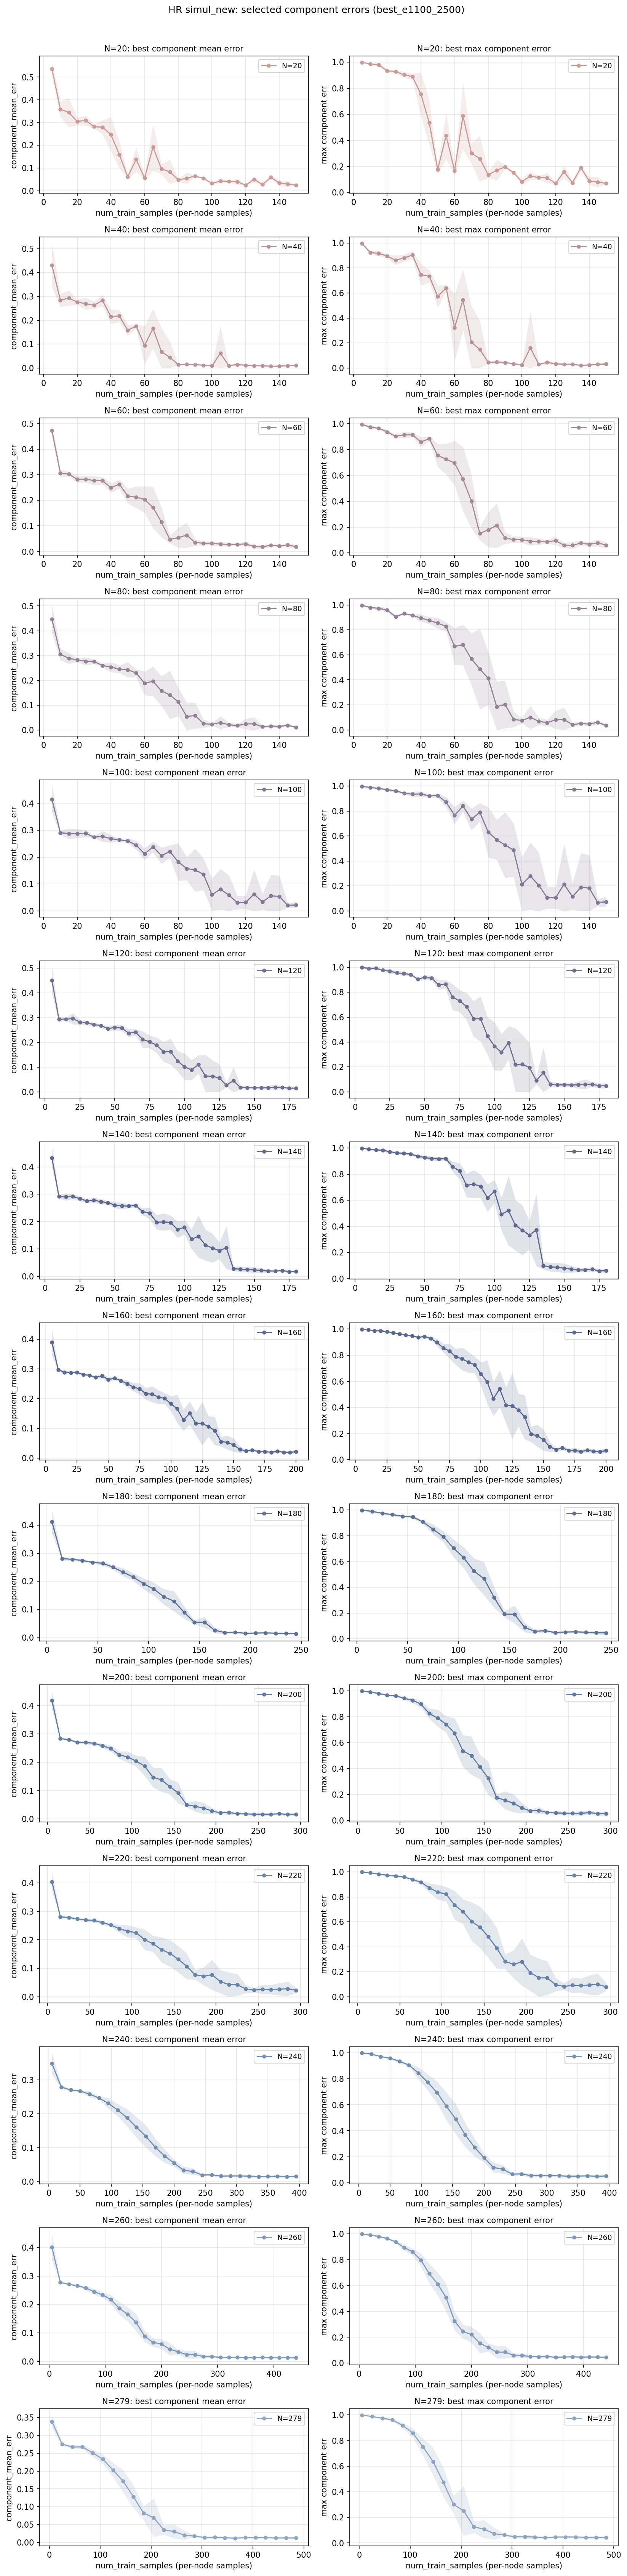

In [28]:
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
n_rows = len(node_counts)
fig, axes = plt.subplots(n_rows, 2,
                         figsize=(11, 3.2 * n_rows),
                         sharex=False, sharey=False, dpi=150)
if n_rows == 1:
    axes = np.array([axes])

for r, n in enumerate(node_counts):
    s = agg[agg.num_nodes_keep == n].sort_values('num_train_samples')
    if s.empty:
        continue
    x = s['num_train_samples'].values
    c = node_color[n]

    ax = axes[r, 0]
    y = s['mean_component_mean_err'].values
    yerr = s['std_component_mean_err'].values
    ax.plot(x, y, 'o-', color=c, ms=4, lw=1.4, label=f'N={n}')
    ax.fill_between(x, np.clip(y - yerr, 0, None), y + yerr,
                    color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('component_mean_err')
    ax.set_title(f'N={n}: best component mean error', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='best')

    ax = axes[r, 1]
    y = s['mean_component_max_err'].values
    yerr = s['std_component_max_err'].values
    ax.plot(x, y, 'o-', color=c, ms=4, lw=1.4, label=f'N={n}')
    ax.fill_between(x, np.clip(y - yerr, 0, None), y + yerr,
                    color=c, alpha=0.18, linewidth=0)
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('max component err')
    ax.set_title(f'N={n}: best max component error', fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='best')

fig.suptitle(f'HR simul_new: selected component errors ({plot_tag})',
             y=1.005, fontsize=12)
fig.tight_layout()
plt.show()


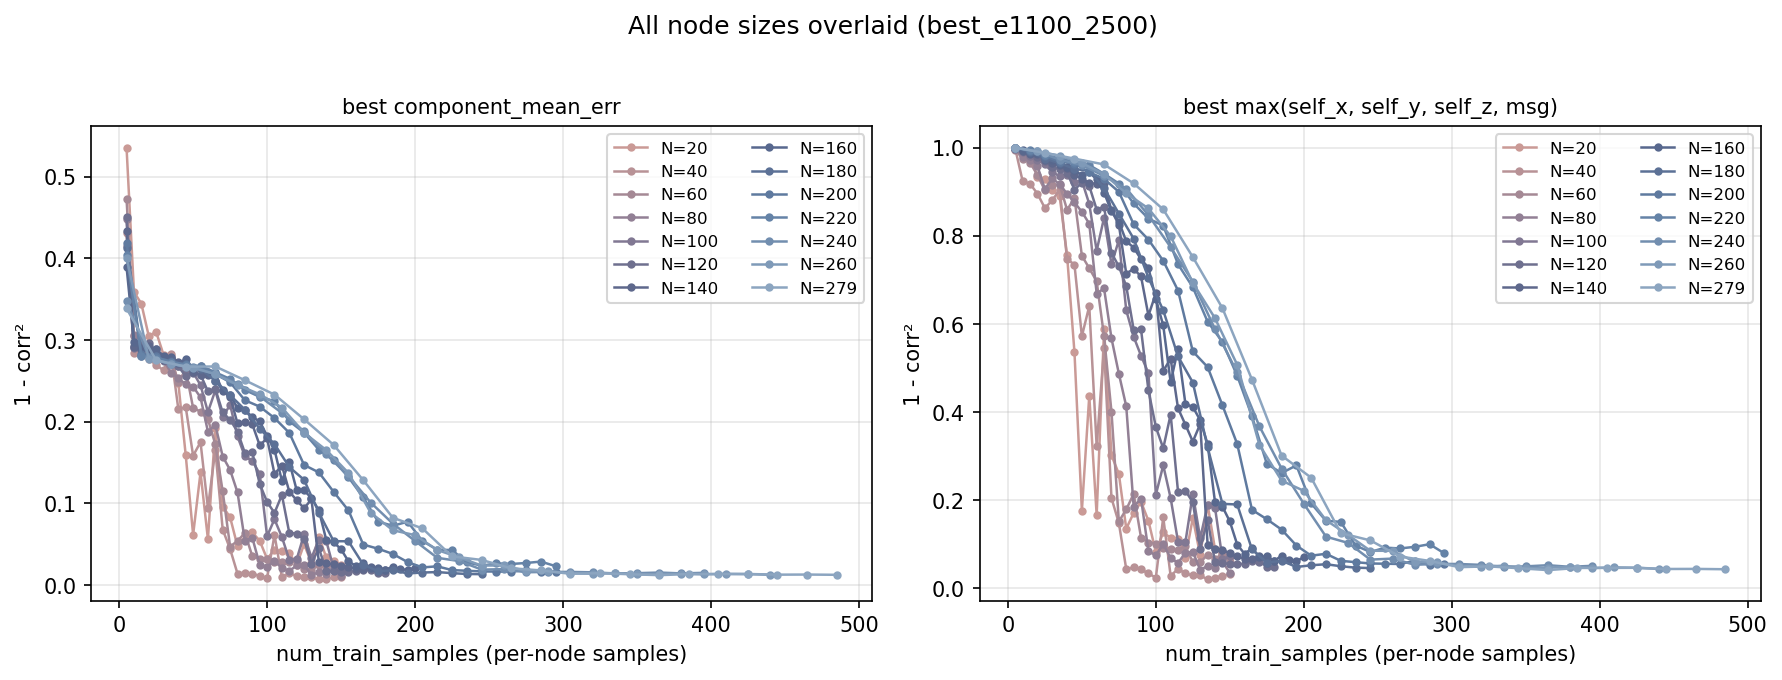

In [29]:
plot_tag = f'e{SELECT_EPOCH}' if SELECT_EPOCH is not None else f'best_e{AUTO_EPOCH_MIN}_{AUTO_EPOCH_MAX}'
# Optional overlay: same two metrics but all node sizes on one axis.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), dpi=150)
for n in node_counts:
    s = agg[agg.num_nodes_keep == n].sort_values('num_train_samples')
    if s.empty:
        continue
    x = s['num_train_samples'].values
    c = node_color[n]
    axes[0].plot(x, s['mean_component_mean_err'].values, 'o-', color=c, ms=3, lw=1.2,
                 label=f'N={n}')
    axes[1].plot(x, s['mean_component_max_err'].values, 'o-', color=c, ms=3, lw=1.2,
                 label=f'N={n}')
for ax, title in zip(axes,
                     ['best component_mean_err', 'best max(self_x, self_y, self_z, msg)']):
    ax.set_xlabel('num_train_samples (per-node samples)')
    ax.set_ylabel('1 - corr²')
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, loc='best', ncol=2)
fig.suptitle(f'All node sizes overlaid ({plot_tag})', y=1.02)
fig.tight_layout()
plt.show()


### Phase diagram: $m_S$ vs $N$ for HR simul_new

For each run we find **$m_S$** = the value of `num_train_samples` at which the
$\max(\mathrm{self\_x\_err},\mathrm{self\_y\_err},\mathrm{self\_z\_err},\mathrm{msg\_err})$
curve (i.e. the `component_max_err` column) first crosses a fixed baseline
$\varepsilon $. Two reference curves are overlaid (style / alpha flip at
their intersection):

- $m_\mathrm{T} = N - 1$ — topology lower bound.
- $m_\mathrm{D} = c / N$ — total-data lower bound. For HR we use $c = 1500$.

In [31]:
def epsilon_S_crossing(xs, ys, y0):
    """Linear-interp x at which y(x) first crosses y0; nan if no crossing."""
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    order = np.argsort(xs)
    xs, ys = xs[order], ys[order]
    if len(xs) < 2:
        return np.nan
    for i in range(len(xs) - 1):
        y1, y2 = ys[i], ys[i + 1]
        if (y1 - y0) * (y2 - y0) <= 0 and y1 != y2:
            t = (y0 - y1) / (y2 - y1)
            return round(float(xs[i] + t * (xs[i + 1] - xs[i])), 2)
    return np.nan

baseline epsilon       = 0.08
c (HR)                 = 1500
crossover c/N vs N - 1 : N ≈ 39.23


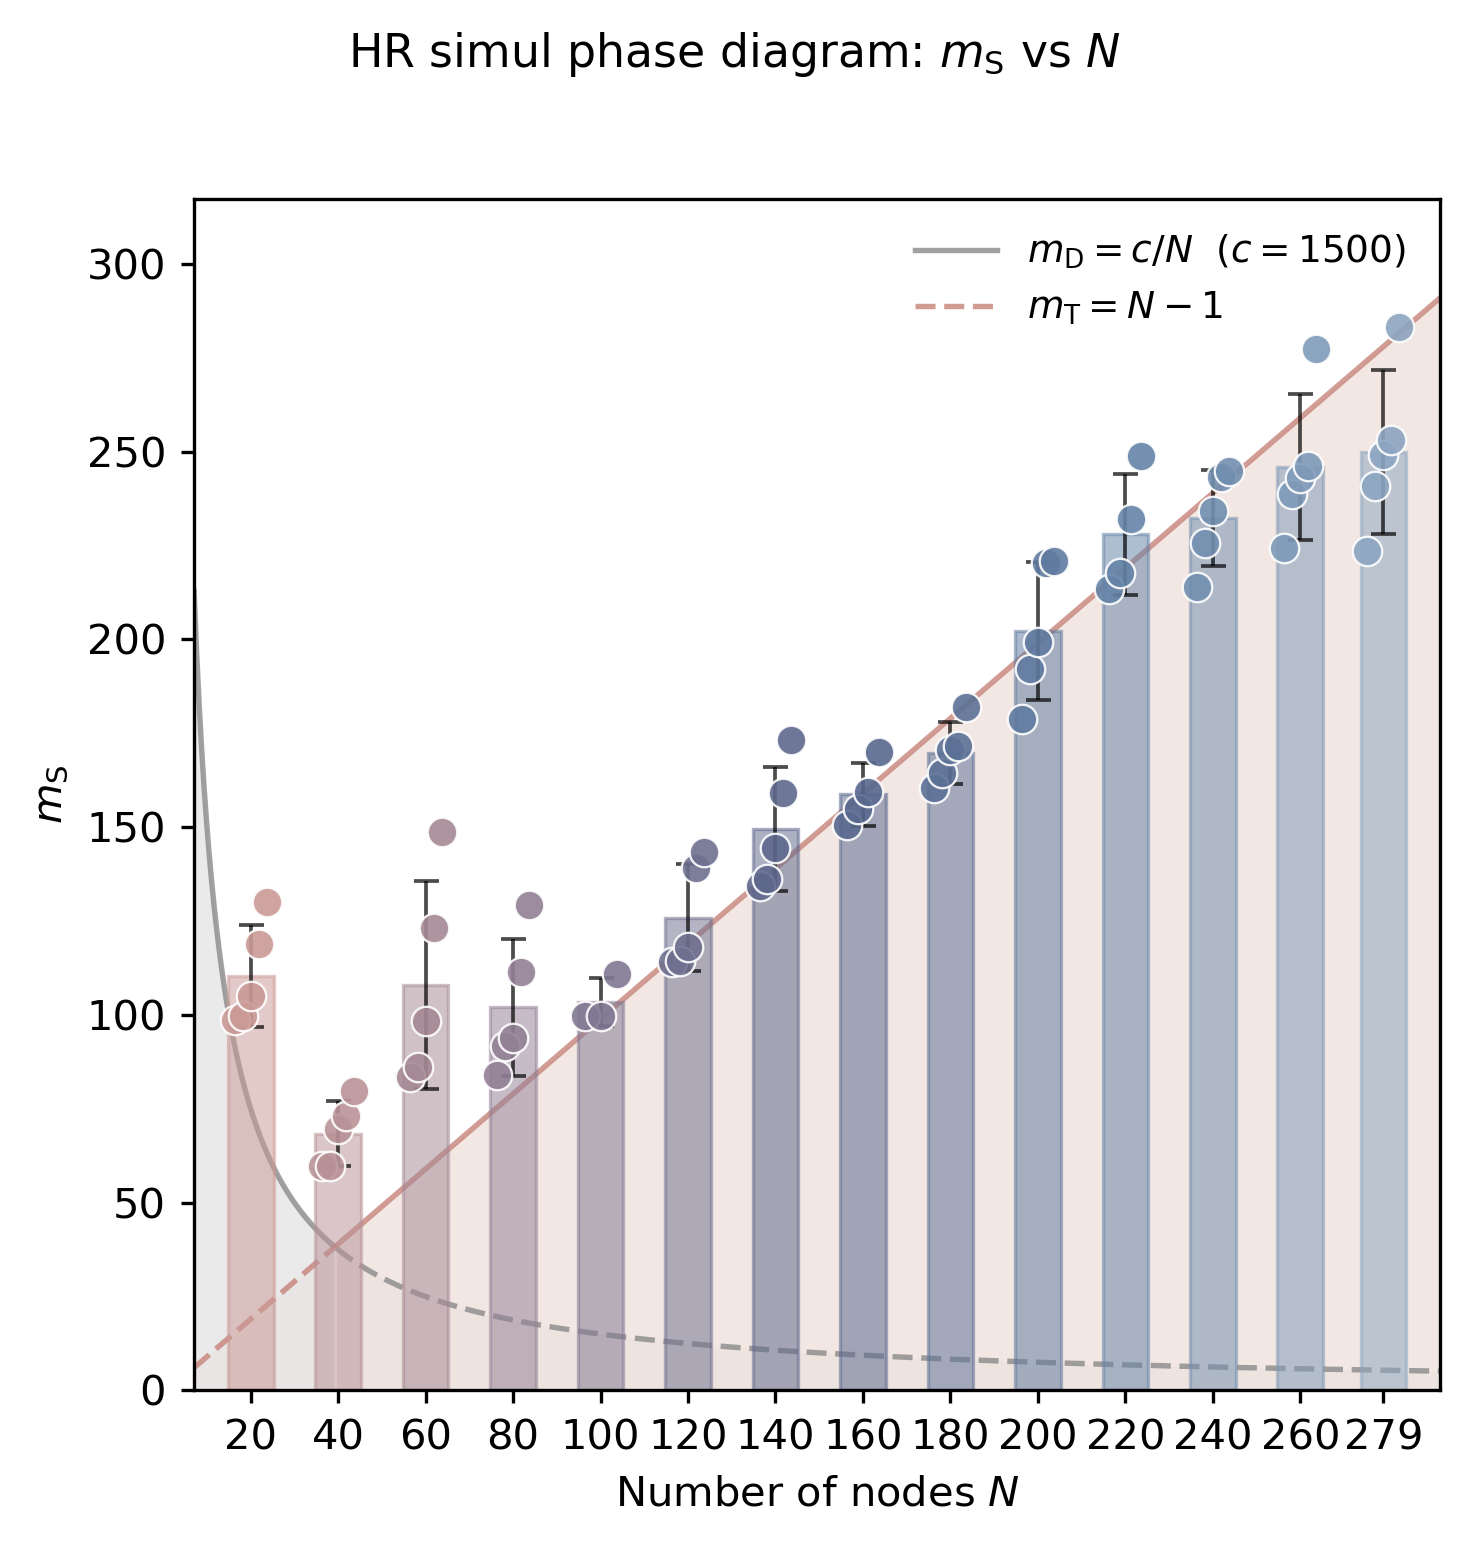

In [34]:
from matplotlib.colors import LinearSegmentedColormap, to_hex
from scipy.optimize import brentq

# ---- phase-diagram settings ----
BASELINE = 0.08                    # crossing threshold on max-component err
ERR_COL  = 'component_max_err'     # max(self_x, self_y, self_z, msg) in 1-corr² units
C_FIT    = 1500                    # HR: m_D = c / N with c = 1000

seeds_sorted = sorted(metrics_df.seed.unique())

# 1) per-seed crossings -> grouped[N] = list of m_S values
grouped = {}
for n in node_counts:
    grouped[n] = []
    for seed in seeds_sorted:
        s = metrics_df[(metrics_df.num_nodes_keep == n)
                       & (metrics_df.seed == seed)].sort_values('num_train_samples')
        if s.empty:
            continue
        xc = epsilon_S_crossing(s.num_train_samples.values, s[ERR_COL].values, BASELINE)
        if np.isfinite(xc):
            grouped[n].append(float(xc))

# 2) crossover point c / N == N - 1 with user-specified c
try:
    x_cross_pt = brentq(lambda x: C_FIT / x - (x - 1), 1.5, 1000)
except Exception:
    x_cross_pt = float(np.sqrt(C_FIT + 0.25) + 0.5)

print(f'baseline epsilon       = {BASELINE}')
print(f'c (HR)                 = {C_FIT}')
print(f'crossover c/N vs N - 1 : N ≈ {x_cross_pt:.2f}')

# 3) style
COLORS = {
    "fill_inv":    "#D9D9D9",
    "line_inv":    "#8A8A8A",
    "fill_diag":   "#E8D5CD",
    "line_diag":   "#C6837A",
}
# node_cmap = LinearSegmentedColormap.from_list(
#     "nature_like_nodes", ["#B08A7A", "#6F8F8D", "#5E6F8E"])
# node_to_color = {
#     n: to_hex(node_cmap(i / (len(node_counts) - 1))) if len(node_counts) > 1 else "#6F8F8D"
#     for i, n in enumerate(node_counts)
# }

# _cmap = LinearSegmentedColormap.from_list(
#     'hr_nodes', ['#8ca5c0','#6280a5','#56648a','#8d7e95','#ca9a96'])
_cmap = LinearSegmentedColormap.from_list(
    'hr_nodes', ['#ca9a96','#8d7e95','#56648a','#6280a5','#8ca5c0'])
node_to_color = {
    n: to_hex(_cmap(i / max(len(node_counts) - 1, 1)))
    for i, n in enumerate(node_counts)
}

nc = np.array(node_counts, dtype=float)
min_gap = float(np.min(np.diff(nc))) if len(nc) > 1 else 2.0
BAR_WIDTH = min_gap * 0.55

# 4) plot: x-axis covers the observed HR node range with a small margin
X_MIN = max(1.0, float(nc.min()) - 0.05 * float(nc.ptp() or 1.0))
X_MAX = float(nc.max()) + 0.05 * float(nc.ptp() or 1.0)
fig, ax = plt.subplots(figsize=(5.0, 5.0), dpi=300)

xref = np.linspace(X_MIN, X_MAX, 500)
mask_left  = xref <= x_cross_pt
mask_right = xref >  x_cross_pt
y_inv  = C_FIT / xref
y_diag = xref - 1

# filled regions, alpha flip at the crossover
ax.fill_between(xref[mask_left],  0, y_inv[mask_left],
                color=COLORS["fill_inv"],  alpha=0.55, linewidth=0, zorder=0)
ax.fill_between(xref[mask_right], 0, y_inv[mask_right],
                color=COLORS["fill_inv"],  alpha=0.20, linewidth=0, zorder=0)
ax.fill_between(xref[mask_left],  0, y_diag[mask_left],
                color=COLORS["fill_diag"], alpha=0.20, linewidth=0, zorder=0)
ax.fill_between(xref[mask_right], 0, y_diag[mask_right],
                color=COLORS["fill_diag"], alpha=0.55, linewidth=0, zorder=0)

# reference curves, solid on dominant side
ax.plot(xref[mask_left],  y_inv[mask_left],  color=COLORS["line_inv"], lw=1.3,
        ls='-',  alpha=0.8, zorder=1,
        label=rf'$m_\mathrm{{D}}=c/N$  ($c={C_FIT}$)')
ax.plot(xref[mask_right], y_inv[mask_right], color=COLORS["line_inv"], lw=1.3,
        ls='--', alpha=0.8, zorder=1)
ax.plot(xref[mask_left],  y_diag[mask_left],  color=COLORS["line_diag"], lw=1.3,
        ls='--', alpha=0.8, zorder=1, label=r'$m_\mathrm{T}=N-1$')
ax.plot(xref[mask_right], y_diag[mask_right], color=COLORS["line_diag"], lw=1.3,
        ls='-',  alpha=0.8, zorder=1)

# per-seed scatter + mean bar
for n in node_counts:
    vals = np.asarray(grouped.get(n, []), dtype=float)
    if len(vals) == 0:
        continue
    vals = np.sort(vals)
    jitter_half = BAR_WIDTH * 0.35
    offsets = (np.linspace(-jitter_half, jitter_half, len(vals))
               if len(vals) > 1 else np.array([0.0]))
    ax.scatter(n + offsets, vals, s=50, color=node_to_color[n],
               edgecolor='white', linewidth=0.55, alpha=0.9, zorder=5)

    mu = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    ax.bar(n, mu, width=BAR_WIDTH, color=node_to_color[n], alpha=0.52,
           edgecolor=node_to_color[n], linewidth=0.8, zorder=2)
    ax.errorbar(n, mu, yerr=sd, fmt='none', ecolor='black', elinewidth=0.9,
                capsize=3, capthick=0.9, alpha=0.7, zorder=4)

# axes / limits
ax.set_xlabel('Number of nodes $N$')
ax.set_ylabel('$m_\mathrm{S}$')
ax.set_xticks(node_counts)
ax.set_xlim(X_MIN, X_MAX)

all_vals = np.concatenate(
    [np.asarray(v, float) for v in grouped.values() if len(v)]
) if any(len(v) for v in grouped.values()) else np.array([])
ymax_candidates = [1.0]
if len(all_vals):
    ymax_candidates.append(float(np.nanmax(all_vals)))
ymax_candidates.append(float((nc - 1).max()))
ax.set_ylim(0, 1.12 * max(ymax_candidates))

# full frame (all four spines visible) instead of just left+bottom
for side in ('top', 'right', 'left', 'bottom'):
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(0.8)
ax.tick_params(direction='out', length=3.2, width=0.8, top=False, right=False)
ax.legend(loc='upper right', frameon=False, fontsize=9, handlelength=2.2)

fig.suptitle(
    rf'HR simul phase diagram: $m_\mathrm{{S}}$ vs $N$ ',
    y=1.02, fontsize=11)
fig.tight_layout()

# Save vector copies for Adobe Illustrator. Text stays editable thanks to the
# rcParams set in the imports cell (svg.fonttype='none', pdf.fonttype=42).
# _out_base = os.path.join(REPO_DIR, 'HR_dyn',
#                          f'phase_diagram_m_S_vs_N_eps{BASELINE}_c{C_FIT}_new')
# fig.savefig(_out_base + '.pdf', bbox_inches='tight')
# fig.savefig(_out_base + '.svg', bbox_inches='tight')
plt.show()